# Tables and Analysis of results obtained to answer RQ1

In [1]:
import pandas as pd
import numpy as np 
import os
import glob
from pathlib import Path
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
LABELS = {
    "01": "isolcpus removed",
    "02": "nohz_full removed",
    "03": "rcu_nocbs removed",
    "04": "systemd containment removed",
    "05": "IRQ steering removed",
    "06": "boot-params bundle removed",
    "07": "all parameters removed (no isolation)",
    #ok  but a few things."07": "worst case (everything removed)",
    "08": "frequency pinning removed",
}
CEILING_U = {"01": 0.79, "02": 0.94, "03": 0.94, "04": 0.94, "05": 0.94, "06": 0.94, "08": 0.94} #"07": 0.79,
SCENARIO_ORDER = ["01", "02", "03", "04", "05", "06", "08"] #07

PERIOD_US = {"tight": 10000, "soft": 100000}

PERIOD_LABELS = {"tight": "10 ms", "soft": "100 ms"}

frames = []
for scenario in SCENARIO_ORDER:
    for workload in ["model1", "model5"]:
        p = os.path.join("./os-experiments/analysis/data", f"{scenario}-{workload}.csv")
        if not os.path.exists(p):
            print(f"missing: {p}"); continue
        df = pd.read_csv(p)
        df["scenario"] = scenario
        df["workload"] = workload
        frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df["normalized_R"] = all_df["R_wall_us"] / (all_df["scale"].map({"tight": 10000, "soft": 100000}))
all_df["deadline_violated"] = all_df["deadline_miss"].astype(bool)
all_df["normalized_C"] = all_df["C_cputime_us"] / (all_df["scale"].map({"tight": 10000, "soft": 100000}))
print(f"{len(all_df)} rows, scenarios={sorted(all_df.scenario.unique())}, workloads={sorted(all_df.workload.unique())}")



BASELINE_MODEL_DIR = {"model1": "model1", "model5": "model5-phys", "model5-smt": "model5-smt"}   # confirm model1 mapping above
baseline_frames = []
for workload, dirname in BASELINE_MODEL_DIR.items():
    df = pd.read_csv(f"./kubedeadline-experiments/analysis/data/{dirname}.csv")
    df["workload"] = workload
    baseline_frames.append(df)
    
baseline_df = pd.concat(baseline_frames, ignore_index=True)
baseline_df["normalized_R"] = baseline_df["R_wall_us"] / baseline_df["scale"].map(PERIOD_US)
baseline_df["normalized_C"] = baseline_df["C_cputime_us"] / baseline_df["scale"].map(PERIOD_US)
print(f"baseline: {len(baseline_df)} rows, workloads={sorted(baseline_df.workload.unique())}")

5320000 rows, scenarios=['01', '02', '03', '04', '05', '06', '08'], workloads=['model1', 'model5']


baseline: 1980000 rows, workloads=['model1', 'model5', 'model5-smt']


#### Distribution tables and Bootstrap CI

In [3]:
def block_bootstrap_ci(values, stat_fn, block_size=100, n_boot=500, ci=0.95, seed=0):
    """Moving block bootstrap CI. values must already be in time order."""
    values = np.asarray(values)
    n = len(values)
    if n < block_size:
        return np.nan, np.nan
    n_blocks = n // block_size
    rng = np.random.default_rng(seed)
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        starts = rng.integers(0, n - block_size + 1, size=n_blocks)
        sample = np.concatenate([values[s:s + block_size] for s in starts])
        boot_stats[i] = stat_fn(sample)
    lo, hi = np.quantile(boot_stats, [(1 - ci) / 2, 1 - (1 - ci) / 2])
    return lo, hi


def wilson_ci(k, n, z=1.96):
    """Standard Wilson score interval -- assumes i.i.d. jobs, no time correlation."""
    if n == 0:
        return np.nan, np.nan
    phat = k / n
    denom = 1 + z**2 / n
    center = phat + z**2 / (2 * n)
    adj = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))
    return max(0.0, (center - adj) / denom), min(1.0, (center + adj) / denom)

#### Distributions R and C in absolute values

In [4]:
STAT_COLS = ["median", "p99", "p99_9", "max"]          # dropped p75, redundant with median
SCALE_ORDER = ["soft", "tight"]                          # side-by-side column groups now
PERIOD_LABELS = {"tight": "tight (10ms)", "soft": "soft (100ms)"}
WORKLOAD_LABELS = {"model1": "single-core", "model5": "multi-core on physical cores"}
DISPLAY_U = [0.1, 0.5, 0.7, 0.94]
BASELINE_LABEL = "baseline (full isolation)"
SMT_LABEL = "SMT enabled (multi-core)"

# absolute-time (ms) columns alongside the existing normalized ones
all_df["R_ms"] = all_df["R_wall_us"] / 1000
all_df["C_ms"] = all_df["C_cputime_us"] / 1000
baseline_df["R_ms"] = baseline_df["R_wall_us"] / 1000
baseline_df["C_ms"] = baseline_df["C_cputime_us"] / 1000

def _stats(vals, outlier_thresh=None):
    n = len(vals)
    out = {
        "median": np.median(vals), "p99": np.percentile(vals, 99),
        "p99_9": np.percentile(vals, 99.9) if n >= 10000 else np.nan,
        "max": vals.max(),
    }
    if outlier_thresh is not None:
        out["n_ge_2x"] = int((vals >= outlier_thresh).sum())
    return out

def build_dist_table(df, metric, workload, u_values=DISPLAY_U, outlier_thresh=2.0, extra_rows=None):
    """extra_rows: list of (label, source_df) pairs, each ONE standalone scenario block
    (like baseline) -- grouped only by (scale, U), never swept across 01-08. Use for
    one-off configs like SMT-enabled, not a per-lever sweep."""
    extra_rows = extra_rows or []
    sub = df[(df.workload == workload) & (df.U.isin(u_values))]
    long_rows = []
    for (scenario, scale, u), g in sub.groupby(["scenario", "scale", "U"]):
        row = {"label": LABELS.get(scenario, scenario), "scale": scale, "U": u}
        row.update(_stats(g[metric].to_numpy(), outlier_thresh))
        long_rows.append(row)

    base_sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.U.isin(u_values))]
    for (scale, u), g in base_sub.groupby(["scale", "U"]):
        row = {"label": BASELINE_LABEL, "scale": scale, "U": u}
        row.update(_stats(g[metric].to_numpy(), outlier_thresh))
        long_rows.append(row)

    for extra_label, extra_df in extra_rows:
        extra_sub = extra_df[extra_df.U.isin(u_values)]
        for (scale, u), g in extra_sub.groupby(["scale", "U"]):
            row = {"label": extra_label, "scale": scale, "U": u}
            row.update(_stats(g[metric].to_numpy(), outlier_thresh))
            long_rows.append(row)

    long_df = pd.DataFrame(long_rows)
    base_p99 = long_df[long_df.label == BASELINE_LABEL].set_index(["scale", "U"])["p99"]
    long_df["p99_ratio"] = [
        p99 / base_p99.get((s, u), np.nan)
        for p99, s, u in zip(long_df["p99"], long_df["scale"], long_df["U"])
    ]
    long_df["scale"] = long_df["scale"].map(PERIOD_LABELS)
    long_df["U"] = long_df["U"].map(lambda u: f"{u:g}")
    out_cols = STAT_COLS + (["n_ge_2x"] if outlier_thresh is not None else []) + ["p99_ratio"]

    labels_in_order = [BASELINE_LABEL] + [LABELS.get(s, s) for s in SCENARIO_ORDER] + [lbl for lbl, _ in extra_rows]
    row_index = pd.MultiIndex.from_product([labels_in_order, [f"{u:g}" for u in u_values]], names=["label", "U"])
    col_index = pd.MultiIndex.from_product([[PERIOD_LABELS[s] for s in SCALE_ORDER], out_cols], names=["scale", "stat"])

    pivot = long_df.set_index(["label", "U", "scale"])[out_cols].unstack("scale")
    pivot.columns = pivot.columns.reorder_levels([1, 0])
    pivot = pivot.reindex(columns=col_index).reindex(row_index)
    return pivot.round(3)

smt_df = baseline_df[baseline_df.workload == "model5-smt"]   # one-off config, sourced like baseline, not a lever sweep

# model1 -- untouched, no SMT concept for single-core
model1_R = build_dist_table(all_df, "normalized_R", "model1")
model1_C = build_dist_table(all_df, "normalized_C", "model1")
model1_R_abs = build_dist_table(all_df, "R_ms", "model1", outlier_thresh=None)
model1_C_abs = build_dist_table(all_df, "C_ms", "model1", outlier_thresh=None)

# model5 -- SMT folded in as one extra scenario-like row, not swept across 01-08
model5_R = build_dist_table(all_df, "normalized_R", "model5", extra_rows=[(SMT_LABEL, smt_df)])
model5_C = build_dist_table(all_df, "normalized_C", "model5", extra_rows=[(SMT_LABEL, smt_df)])
model5_R_abs = build_dist_table(all_df, "R_ms", "model5", outlier_thresh=None, extra_rows=[(SMT_LABEL, smt_df)])
model5_C_abs = build_dist_table(all_df, "C_ms", "model5", outlier_thresh=None, extra_rows=[(SMT_LABEL, smt_df)])

for metric, m1, m5 in [("R", model1_R, model5_R), ("C", model1_C, model5_C),
                        ("R_abs_ms", model1_R_abs, model5_R_abs), ("C_abs_ms", model1_C_abs, model5_C_abs)]:
    merged = pd.concat({WORKLOAD_LABELS["model1"]: m1, WORKLOAD_LABELS["model5"]: m5}, names=["workload"])
    merged.to_csv(f"./os-experiments/analysis/results/{metric}_dist.csv")
    print(f"saved: {metric}_dist.csv")

LABEL_TO_SCENARIO = {v: k for k, v in LABELS.items()}

def display_dist_table(table, workload, metric_label, metric_unit, normalized=True):
    def above_cap(label, u):
        code = LABEL_TO_SCENARIO.get(label)
        return code is not None and float(u) > CEILING_U.get(code, 1.0)

    disp = pd.DataFrame(index=table.index, columns=table.columns, dtype=object)
    for label, u in table.index:
        capped = above_cap(label, u)
        for col in table.columns:
            v = table.loc[(label, u), col]
            if pd.isna(v):
                disp.loc[(label, u), col] = "— (above OS cap)" if capped else ""
            else:
                stat = col[1]
                disp.loc[(label, u), col] = f"{int(v)}" if stat == "n_ge_2x" else f"{v:.3f}"

    stat_cols = [c for c in disp.columns if c[1] not in ("n_ge_2x", "p99_ratio")]
    ratio_cols = [c for c in disp.columns if c[1] == "p99_ratio"]

    def highlight_miss(v):
        try:
            return "font-weight: bold; color: #b00020" if float(v) >= 1.0 else ""
        except (ValueError, TypeError):
            return ""

    def highlight_ratio(v):
        try:
            return "font-style: italic; color: #7a4d00" if float(v) >= 1.2 else ""
        except (ValueError, TypeError):
            return ""

    styled = disp.style
    if normalized:
        styled = styled.map(highlight_miss, subset=stat_cols)
    caption = f"{WORKLOAD_LABELS[workload]}, {metric_label}. Unit: {metric_unit}. "
    if normalized:
        caption += "Bold/red = value ≥ 1.0 (deadline miss). "
    if "n_ge_2x" in [c[1] for c in table.columns]:
        caption += "'n_ge_2x' = number of jobs ≥ 2× deadline (out of the group's sample size). "
    caption += (f"'p99_ratio' = p99 relative to {BASELINE_LABEL} at the same (scale, U); "
                f"italic/orange = ≥ 1.2× baseline. "
                f"'— (above OS cap)' = U exceeds this scenario's admission ceiling.")
    styled = styled.map(highlight_ratio, subset=ratio_cols)
    return styled.set_caption(caption)

display_dist_table(model5_R, "model5", "response time (R)", "R / deadline; ≥ 1.0 = miss")


saved: R_dist.csv
saved: C_dist.csv
saved: R_abs_ms_dist.csv
saved: C_abs_ms_dist.csv


#### Deadline miss rate vs (scenario x Utilization)

In [5]:
from scipy.stats import beta

def clopper_pearson_upper(k, n, alpha=0.05):
    if n == 0:
        return np.nan
    return 1.0 if k == n else beta.ppf(1 - alpha / 2, k + 1, n - k)

def build_miss_rate_tables(df, workload, u_values=DISPLAY_U, extra_rows=None):
    """extra_rows: list of (label, source_df) pairs, each ONE standalone scenario block
    (like baseline) -- grouped only by (scale, U), never swept across 01-08."""
    extra_rows = extra_rows or []
    sub = df[(df.workload == workload) & (df.U.isin(u_values))]
    long_rows = []
    for (scenario, scale, u), g in sub.groupby(["scenario", "scale", "U"]):
        n = len(g)
        k = int((g["R_wall_us"] >= PERIOD_US[scale]).sum())
        hi = clopper_pearson_upper(k, n)
        long_rows.append({"label": LABELS.get(scenario, scenario), "scale": PERIOD_LABELS.get(scale, scale),
                            "U": f"{u:g}", "n": n, "misses": k,
                            "rate_pct": 100 * k / n, "upper_pct": 100 * hi})

    base_sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.U.isin(u_values))]
    for (scale, u), g in base_sub.groupby(["scale", "U"]):
        n = len(g)
        k = int((g["R_wall_us"] >= PERIOD_US[scale]).sum())
        hi = clopper_pearson_upper(k, n)
        long_rows.append({"label": BASELINE_LABEL, "scale": PERIOD_LABELS.get(scale, scale),
                            "U": f"{u:g}", "n": n, "misses": k,
                            "rate_pct": 100 * k / n, "upper_pct": 100 * hi})

    for extra_label, extra_df in extra_rows:
        extra_sub = extra_df[extra_df.U.isin(u_values)]
        for (scale, u), g in extra_sub.groupby(["scale", "U"]):
            n = len(g)
            k = int((g["R_wall_us"] >= PERIOD_US[scale]).sum())
            hi = clopper_pearson_upper(k, n)
            long_rows.append({"label": extra_label, "scale": PERIOD_LABELS.get(scale, scale),
                                "U": f"{u:g}", "n": n, "misses": k,
                                "rate_pct": 100 * k / n, "upper_pct": 100 * hi})

    long_df = pd.DataFrame(long_rows)
    labels_in_order = [BASELINE_LABEL] + [LABELS.get(s, s) for s in SCENARIO_ORDER] + [lbl for lbl, _ in extra_rows]
    u_labels = [f"{u:g}" for u in u_values]
    col_index = pd.MultiIndex.from_product([[PERIOD_LABELS[s] for s in SCALE_ORDER], u_labels], names=["scale", "U"])

    def pivot(field):
        p = long_df.pivot_table(index="label", columns=["scale", "U"], values=field, aggfunc="first")
        return p.reindex(index=labels_in_order, columns=col_index)

    return pivot("rate_pct"), pivot("upper_pct"), pivot("n")

LABEL_TO_SCENARIO = {v: k for k, v in LABELS.items()}

def display_miss_rate_table(rate_p, upper_p, n_p, workload, cmap="Reds"):
    def above_cap(label, col):
        code = LABEL_TO_SCENARIO.get(label)
        return code is not None and float(col[1]) > CEILING_U.get(code, 1.0)

    disp = pd.DataFrame(index=rate_p.index, columns=rate_p.columns, dtype=object)
    for label in rate_p.index:
        for col in rate_p.columns:
            r = rate_p.loc[label, col]
            if pd.isna(r):
                disp.loc[label, col] = "—" if above_cap(label, col) else ""
            elif r == 0:
                disp.loc[label, col] = "0"
            else:
                disp.loc[label, col] = f"{r:.3f}"

    log_gmap = np.log10(upper_p.astype(float) + 0.001)

    n_valid = n_p.to_numpy(dtype=float)
    n_valid = n_valid[~np.isnan(n_valid)]
    typical_n = int(np.median(n_valid)) if len(n_valid) else None
    n_lo, n_hi = (int(n_valid.min()), int(n_valid.max())) if len(n_valid) else (None, None)
    n_note = f"n ≈ {typical_n} jobs/cell" if n_lo == n_hi else f"n ≈ {n_lo}–{n_hi} jobs/cell"
    zero_upper = clopper_pearson_upper(0, typical_n) * 100 if typical_n else float("nan")
    return (disp.style
        .background_gradient(cmap=cmap, gmap=log_gmap, axis=None)
        .highlight_null(color="white"))

model1_rate, model1_upper, model1_n = build_miss_rate_tables(all_df, "model1")
model5_rate, model5_upper, model5_n = build_miss_rate_tables(all_df, "model5", extra_rows=[(SMT_LABEL, smt_df)])

merged_rate = pd.concat({WORKLOAD_LABELS["model1"]: model1_rate, WORKLOAD_LABELS["model5"]: model5_rate},
                        names=["workload"])
merged_rate.to_csv("./os-experiments/analysis/results/miss_rate_pct.csv")
print("saved: miss_rate_pct.csv")

display_miss_rate_table(model5_rate, model5_upper, model5_n, "model5")


saved: miss_rate_pct.csv


In [6]:
display_miss_rate_table(model5_rate, model5_upper, model5_n, "model5")

#### (m, k)- analysis

In [7]:
def longest_miss_run(met):
    miss = 1 - np.asarray(met, dtype=int)
    runs = np.diff(np.flatnonzero(np.diff(np.r_[0, miss, 0])))[::2]
    return int(runs.max()) if runs.size else 0
    
def max_misses(met, k):
    miss = 1 - np.asarray(met, dtype=int)
    n = len(miss)
    if n < k:
        return np.nan
    csum = np.concatenate(([0], np.cumsum(miss)))
    return int((csum[k:] - csum[:-k]).max())
        
def max_misses_independent(n, p, k, sims=300, q=95, rng=None):
    if n < k or p is None or np.isnan(p):
        return np.nan
    rng = rng or np.random.default_rng(0)
    miss = (rng.random((sims, n)) < p).astype(np.int32)
    csum = np.concatenate([np.zeros((sims, 1), dtype=np.int32), np.cumsum(miss, axis=1)], axis=1)
    window_sums = csum[:, k:] - csum[:, :-k]
    return float(np.percentile(window_sums.max(axis=1), q))

    
K_VALUES_WH = (50, 100)
    
def _weakly_hard_stats(g, k_values=K_VALUES_WH):
    per_round_max = {k: [] for k in k_values}
    per_round_run = []
    n_total = misses_total = 0 
    for _, rg in g.sort_values(["round", "job_index"]).groupby("round"):
        met = 1 - rg["deadline_miss"].to_numpy(dtype=int)
        for k in k_values:
            mk = max_misses(met, k)
            if not np.isnan(mk):
                per_round_max[k].append(mk)
        per_round_run.append(longest_miss_run(met))
        n_total += len(met)
        misses_total += int(rg["deadline_miss"].sum())
    out = {"n": n_total}
    p_hat = misses_total / n_total if n_total else np.nan
    for k in k_values:
        out[f"max_misses_k{k}"] = max(per_round_max[k]) if per_round_max[k] else np.nan
        out[f"expected_k{k}"] = max_misses_independent(n_total, p_hat, k)
    out["longest_run"] = max(per_round_run) if per_round_run else np.nan
    return out

def build_weakly_hard_tables(df, workload, u_values=DISPLAY_U, k_values=K_VALUES_WH, extra_rows=None):
    """extra_rows: list of (label, source_df) pairs, each ONE standalone scenario block
    (like baseline) -- grouped only by (scale, U), never swept across 01-08."""
    extra_rows = extra_rows or []
    sub = df[(df.workload == workload) & (df.U.isin(u_values))]
    long_rows = []
    for (scenario, scale, u), g in sub.groupby(["scenario", "scale", "U"]):
        row = {"label": LABELS.get(scenario, scenario), "scale": PERIOD_LABELS.get(scale, scale), "U": f"{u:g}"}
        row.update(_weakly_hard_stats(g, k_values))
        long_rows.append(row)
        
    base_sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.U.isin(u_values))]
    for (scale, u), g in base_sub.groupby(["scale", "U"]):
        row = {"label": BASELINE_LABEL, "scale": PERIOD_LABELS.get(scale, scale), "U": f"{u:g}"}
        row.update(_weakly_hard_stats(g, k_values))
        long_rows.append(row)

    for extra_label, extra_df in extra_rows:
        extra_sub = extra_df[extra_df.U.isin(u_values)]
        for (scale, u), g in extra_sub.groupby(["scale", "U"]):
            row = {"label": extra_label, "scale": PERIOD_LABELS.get(scale, scale), "U": f"{u:g}"}
            row.update(_weakly_hard_stats(g, k_values))
            long_rows.append(row)
        
    long_df = pd.DataFrame(long_rows)
    labels_in_order = [BASELINE_LABEL] + [LABELS.get(s, s) for s in SCENARIO_ORDER] + [lbl for lbl, _ in extra_rows]
    u_labels = [f"{u:g}" for u in u_values]
    col_index = pd.MultiIndex.from_product([[PERIOD_LABELS[s] for s in SCALE_ORDER], u_labels], names=["scale", "U"])
    
    def pivot(field):
        p = long_df.pivot_table(index="label", columns=["scale", "U"], values=field, aggfunc="first")
        return p.reindex(index=labels_in_order, columns=col_index)
    
    tables = {"n": pivot("n"), "longest_run": pivot("longest_run")}
    for k in k_values:
        tables[f"max_misses_k{k}"] = pivot(f"max_misses_k{k}")
        tables[f"expected_k{k}"] = pivot(f"expected_k{k}")
    return tables


In [8]:
def display_weakly_hard_table(tables, k, workload, cmap="Reds"):
    obs_p, n_p = tables[f"max_misses_k{k}"], tables["n"]
    
    def above_cap(label, col):
        code = LABEL_TO_SCENARIO.get(label)
        return code is not None and float(col[1]) > CEILING_U.get(code, 1.0)
    
    disp = pd.DataFrame(index=obs_p.index, columns=obs_p.columns, dtype=object)
    for label in obs_p.index:
        for col in obs_p.columns:
            v = obs_p.loc[label, col]
            if pd.isna(v):
                disp.loc[label, col] = "—" if above_cap(label, col) else ""
            else: 
                m = k - int(v)   # observed m: at least m out of k met their deadline
                disp.loc[label, col] = f"({m},{k})"
    
    n_valid = n_p.to_numpy(dtype=float)
    n_valid = n_valid[~np.isnan(n_valid)]
    typical_n = int(np.median(n_valid)) if len(n_valid) else None
    n_lo, n_hi = (int(n_valid.min()), int(n_valid.max())) if len(n_valid) else (None, None)
    n_note = f"n ≈ {typical_n} jobs" if n_lo == n_hi else f"n ≈ {n_lo}–{n_hi} jobs"

    return (disp.style
            .background_gradient(cmap=cmap, gmap=obs_p.astype(float), axis=None)   # colour by max misses, not m -- higher misses = darker
            .highlight_null(color="white"))


def display_burst_evidence_table(tables, k, workload):
    obs_p, exp_p, run_p = tables[f"max_misses_k{k}"], tables[f"expected_k{k}"], tables["longest_run"]
    disp = pd.DataFrame(index=obs_p.index, columns=obs_p.columns, dtype=object)
    for label in obs_p.index:
        for col in obs_p.columns:
            o, e, r = obs_p.loc[label, col], exp_p.loc[label, col], run_p.loc[label, col]
            if pd.isna(o):
                disp.loc[label, col] = "—"
            else:
                ratio = f"{o / e:.1f}×" if e and e > 0 else "n/a"
                disp.loc[label, col] = f"{int(o)} vs {e:.1f} exp ({ratio}), run={int(r)}"
    return disp.style  

model1_wh = build_weakly_hard_tables(all_df, "model1")
model5_wh = build_weakly_hard_tables(all_df, "model5", extra_rows=[(SMT_LABEL, smt_df)])

# only the displayed (m,k) numbers are saved as results -- n/longest_run/expected_k* stay
# in-memory for display_weakly_hard_table/display_burst_evidence_table, not separate files.
# Workload folded into one file per k.
for k in K_VALUES_WH:
    merged = pd.concat({WORKLOAD_LABELS["model1"]: model1_wh[f"max_misses_k{k}"],
                         WORKLOAD_LABELS["model5"]: model5_wh[f"max_misses_k{k}"]}, names=["workload"])
    merged.to_csv(f"./os-experiments/analysis/results/weakly_hard_k{k}.csv")
    print(f"saved: weakly_hard_k{k}.csv")

display_weakly_hard_table(model1_wh, 50, "single core")


saved: weakly_hard_k50.csv
saved: weakly_hard_k100.csv


In [9]:
display_weakly_hard_table(model1_wh, 100, "single core")

In [10]:
display_weakly_hard_table(model5_wh, 50, "multi core")

In [11]:
display_weakly_hard_table(model5_wh, 100, "multi core")

baseline (full isolation), soft (100ms), U=0.94, round=2: 17 misses in 2 episode(s). Worst: 11 misses over 4.00s (starting at t=5552.21s).
  steal_us not logged/all zero for this cell -- can't check cloud-steal correlation


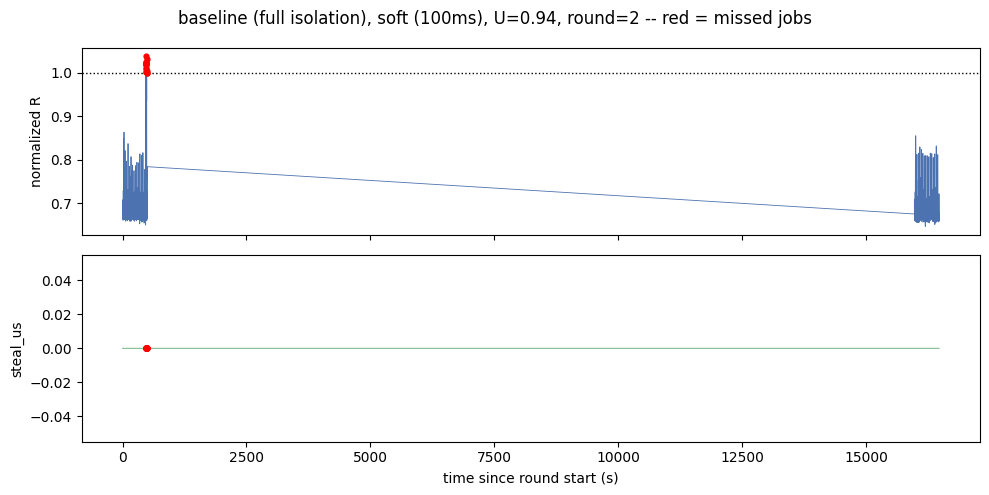

baseline (full isolation), soft (100ms), U=0.94, round=3: 17 misses in 2 episode(s). Worst: 11 misses over 4.00s (starting at t=5552.21s).
  steal_us not logged/all zero for this cell -- can't check cloud-steal correlation


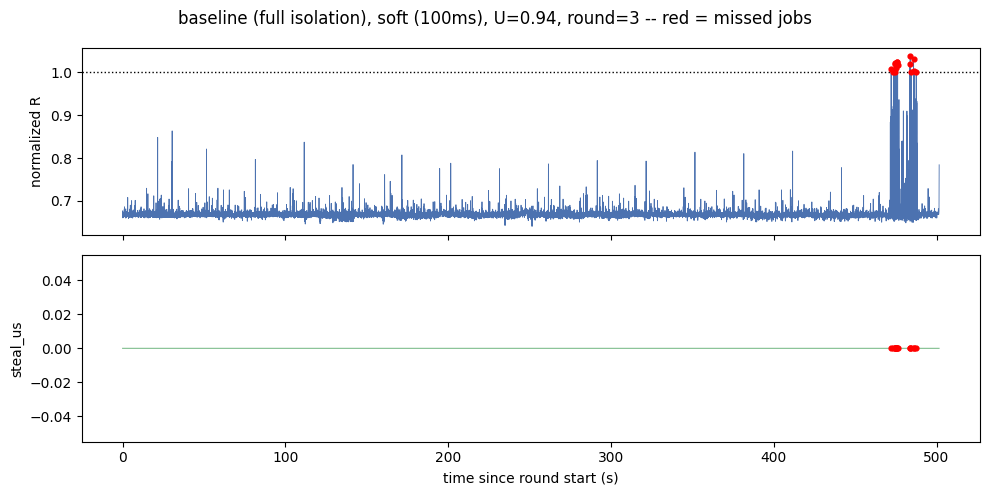

IRQ steering removed, soft (100ms), U=0.94, round=4: 22 misses in 3 episode(s). Worst: 12 misses over 2.20s (starting at t=5543.36s).
  steal_us not logged/all zero for this cell -- can't check cloud-steal correlation


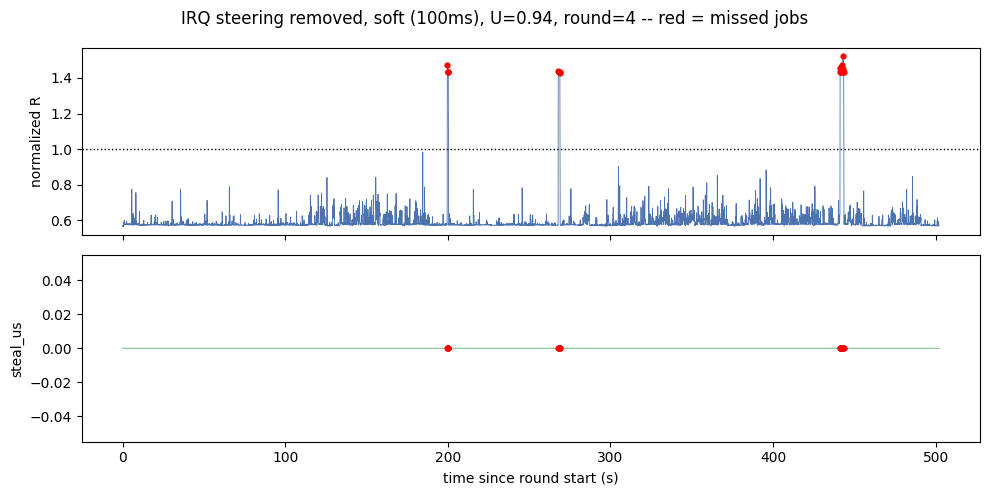

isolcpus removed, soft (100ms), U=0.1, round=1: 411 misses in 14 episode(s). Worst: 84 misses over 112.60s (starting at t=19349.59s).
  steal_us not logged/all zero for this cell -- can't check cloud-steal correlation


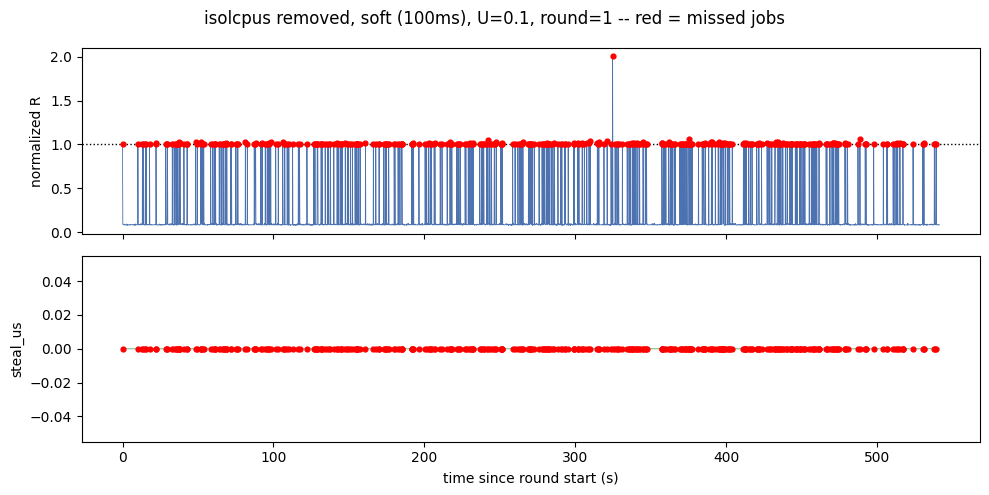

isolcpus removed, soft (100ms), U=0.1, round=2: 81 misses in 29 episode(s). Worst: 11 misses over 28.00s (starting at t=1625.25s).
  steal_us not logged/all zero for this cell -- can't check cloud-steal correlation


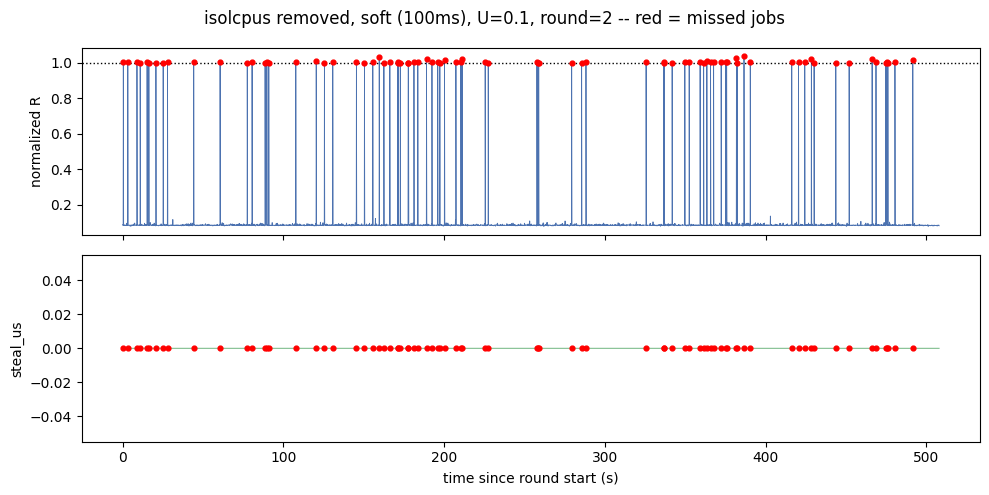

isolcpus removed, soft (100ms), U=0.1, round=4: 4 misses in 4 episode(s). Worst: 1 misses over 0.00s (starting at t=409.32s).
  steal_us not logged/all zero for this cell -- can't check cloud-steal correlation


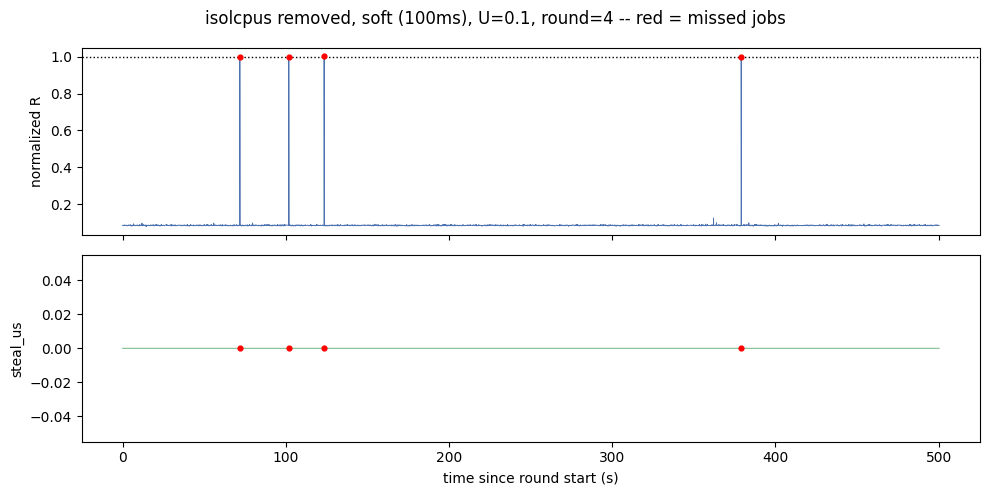

In [12]:
def weakly_hard_curve(workload, scenario_label, scale_raw, u, k_range=range(1, 101)):
    if scenario_label == BASELINE_LABEL:
        sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.scale == scale_raw) & (baseline_df.U == u)]
    else:
        code = LABEL_TO_SCENARIO[scenario_label]
        sub = all_df[(all_df.workload == workload) & (all_df.scenario == code) &
                    (all_df.scale == scale_raw) & (all_df.U == u)]
    met_by_round, n_total, misses_total = [], 0, 0
    for _, rg in sub.sort_values(["round", "job_index"]).groupby("round"):
        met = 1 - rg["deadline_miss"].to_numpy(dtype=int)
        met_by_round.append(met)
        n_total += len(met)
        misses_total += int(rg["deadline_miss"].sum())
    p_hat = misses_total / n_total if n_total else np.nan

    obs, exp = [], []
    for k in k_range:
        vals = [max_misses(met, k) for met in met_by_round if len(met) >= k]
        obs.append(max(vals) if vals else np.nan)
        exp.append(max_misses_independent(n_total, p_hat, k) if n_total >= k else np.nan)
    return np.array(obs), np.array(exp)

def plot_weakly_hard_curves(workload, scale_raw, u, scenario_labels, k_range=range(1, 101)):
    fig, ax = plt.subplots(figsize=(8, 5))
    for label in scenario_labels:
        obs, exp = weakly_hard_curve(workload, label, scale_raw, u, k_range)
        line, = ax.plot(list(k_range), obs, label=f"{label} (observed)")
        ax.plot(list(k_range), exp, linestyle="--", color=line.get_color(), alpha=0.6,
                label=f"{label} (independence, p95)")
    ax.set_xlabel("k (window size, consecutive jobs)")
    ax.set_ylabel("max misses in any window of k")
    ax.set_title(f"{WORKLOAD_LABELS[workload]}, {PERIOD_LABELS[scale_raw]}, U={u}: burstiness check")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

def burst_episodes(release_us, gap_thresh_s=5.0):
    """Group sorted miss timestamps (us) into burst episodes separated by > gap_thresh_s idle gaps."""
    if len(release_us) == 0:
        return []
    t = np.sort(release_us) / 1e6
    gaps = np.diff(t)
    breaks = np.where(gaps > gap_thresh_s)[0]
    starts = np.r_[0, breaks + 1] 
    ends = np.r_[breaks, len(t) - 1]
    return [{"n_misses": e - s + 1, "start_s": t[s], "end_s": t[e], "duration_s": t[e] - t[s]}
            for s, e in zip(starts, ends)]

def investigate_burst(workload, scenario_code, scale_raw, u, gap_thresh_s=5.0, plot=True):
    if scenario_code is None:
        sub = baseline_df[(baseline_df.workload == workload) & (baseline_df.scale == scale_raw) & (baseline_df.U == u)]
        label = BASELINE_LABEL
    else:
        sub = all_df[(all_df.workload == workload) & (all_df.scenario == scenario_code) &
                    (all_df.scale == scale_raw) & (all_df.U == u)]
        label = LABELS[scenario_code]
    
    for round_n, g in sub.sort_values(["round", "job_index"]).groupby("round"):
        g = g.sort_values("release_us")
        miss_mask = g["deadline_miss"] == 1
        misses = g[miss_mask]
        if misses.empty:
            continue

        episodes = burst_episodes(misses["release_us"].to_numpy(), gap_thresh_s)
        worst = max(episodes, key=lambda e: e["n_misses"])
        print(f"{label}, {PERIOD_LABELS[scale_raw]}, U={u}, round={round_n}: "
            f"{len(misses)} misses in {len(episodes)} episode(s). "
            f"Worst: {worst['n_misses']} misses over {worst['duration_s']:.2f}s "
            f"(starting at t={worst['start_s']:.2f}s).")

        if "steal_us" in g.columns and g["steal_us"].notna().any() and g["steal_us"].mean() > 0:
            steal_at_miss = g.loc[miss_mask, "steal_us"].mean()
            steal_overall = g["steal_us"].mean()
            print(f"  mean steal_us at missed jobs: {steal_at_miss:.1f} vs overall: {steal_overall:.1f} "
                  f"(ratio {steal_at_miss / steal_overall:.2f}x)")
        else:     
            print("  steal_us not logged/all zero for this cell -- can't check cloud-steal correlation")
            
        if plot:
            t = (g["release_us"] - g["release_us"].iloc[0]) / 1e6
            fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
            axes[0].plot(t, g["normalized_R"], color="#4c72b0", linewidth=0.6)
            axes[0].scatter(t[miss_mask], g.loc[miss_mask, "normalized_R"], color="red", s=12, zorder=5)
            axes[0].axhline(1.0, color="black", linestyle=":", linewidth=1) 
            axes[0].set_ylabel("normalized R")
            if "steal_us" in g.columns:
                axes[1].plot(t, g["steal_us"], color="#55a868", linewidth=0.6)
                axes[1].scatter(t[miss_mask], g.loc[miss_mask, "steal_us"], color="red", s=12, zorder=5)
                axes[1].set_ylabel("steal_us")
            axes[1].set_xlabel("time since round start (s)")
            fig.suptitle(f"{label}, {PERIOD_LABELS[scale_raw]}, U={u}, round={round_n} -- red = missed jobs")
            fig.tight_layout()
            plt.show()
            
investigate_burst("model5", None, "soft", 0.94)                                          # multi-core baseline
investigate_burst("model5", LABEL_TO_SCENARIO["IRQ steering removed"], "soft", 0.94)      # multi-core, IRQ removed
investigate_burst("model1", LABEL_TO_SCENARIO["isolcpus removed"], "soft", 0.1)           # single-core, isolcpus removed


In [13]:
RESULTS_DIR = Path("os-experiments/analysis/results")
LATEX_DIR = RESULTS_DIR / "latex"
LATEX_DIR.mkdir(exist_ok=True)

# how each CSV's header/index rows were written (2 column levels: scale+stat or scale+U;
# 3 index levels for the dist tables (workload,label,U), 2 for the rest (workload,label))
TABLE_SPECS = {
    "R_dist.csv":          {"header": [0, 1], "index_col": [0, 1, 2], "kind": "dist"},
    "C_dist.csv":          {"header": [0, 1], "index_col": [0, 1, 2], "kind": "dist"},
    "R_abs_ms_dist.csv":   {"header": [0, 1], "index_col": [0, 1, 2], "kind": "abs"},
    "C_abs_ms_dist.csv":   {"header": [0, 1], "index_col": [0, 1, 2], "kind": "abs"},
    "miss_rate_pct.csv":   {"header": [0, 1], "index_col": [0, 1],    "kind": "rate"},
    "weakly_hard_k50.csv": {"header": [0, 1], "index_col": [0, 1],    "kind": "wh", "k": 50},
    "weakly_hard_k100.csv":{"header": [0, 1], "index_col": [0, 1],    "kind": "wh", "k": 100},
}

def load_table(fname, spec):
    return pd.read_csv(RESULTS_DIR / fname, header=spec["header"], index_col=spec["index_col"])

def split_by_workload(df):
    """Drop the outer 'workload' index level, return {workload_name: sub_df}."""
    return {w: df.xs(w, level="workload") for w in df.index.get_level_values("workload").unique()}
    
def to_mk_strings(df, k):
    """Weakly-hard tables store raw max-misses counts -- render as the (m,k) form for the thesis."""
    def fmt(v):
        return "--" if pd.isna(v) else f"({k - int(v)},{k})"
    return df.map(fmt) 
    
def save_latex(df, out_path, caption, label, float_format=None, wide=False):
    tex = df.to_latex(na_rep="--", caption=caption, label=label,
                        multicolumn=True, multicolumn_format="c", escape=True,
                        float_format=float_format)
    tex = polish_latex(tex, wide=wide)
    out_path.write_text(tex)
    print(f"saved: {out_path}")

def clean_u_level(df):
    for axis_name, mindex in [("index", df.index), ("columns", df.columns)]:
        if isinstance(mindex, pd.MultiIndex) and "U" in mindex.names:
            lvl = mindex.names.index("U")
            new_level = mindex.levels[lvl].map(lambda u: f"{float(u):g}")
            mindex = mindex.set_levels(new_level, level=lvl)
            if axis_name == "index":
                df.index = mindex
            else:
                df.columns = mindex
    return df   
            
def polish_latex(tex, wide=False):
    # \cline draws a heavier full rule that can clash with \multirow -- \cmidrule is the
    # booktabs-consistent horizontal separator between each scenario's block of rows.
    tex = re.sub(r"\\cline\{(\d+)-(\d+)\}", r"\\cmidrule{\1-\2}", tex)
    if wide:
        tex = tex.replace(r"\begin{tabular}", "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}", 1)
        tex = tex.replace(r"\end{tabular}", "\\end{tabular}%\n}", 1)
    return tex

for fname, spec in TABLE_SPECS.items():
    df = clean_u_level(load_table(fname, spec))
    stem = fname.replace(".csv", "")
    for workload, sub_df in split_by_workload(df).items():
        if spec["kind"] == "wh":
            sub_df = to_mk_strings(sub_df, spec["k"])
        elif spec["kind"] == "dist":
            sub_df = sub_df.drop(columns="n_ge_2x", level="stat")
        safe_workload = workload.replace(" ", "_")
        out_path = LATEX_DIR / f"{stem}__{safe_workload}.tex"
        fmt = "%.2f"
        save_latex(sub_df, out_path,
                    caption=f"{workload}: {stem.replace('_', ' ')}",
                    label=f"tab:{stem}_{safe_workload}",
                    float_format=fmt, wide=True)



saved: os-experiments/analysis/results/latex/R_dist__single-core.tex
saved: os-experiments/analysis/results/latex/R_dist__multi-core_on_physical_cores.tex
saved: os-experiments/analysis/results/latex/C_dist__single-core.tex
saved: os-experiments/analysis/results/latex/C_dist__multi-core_on_physical_cores.tex
saved: os-experiments/analysis/results/latex/R_abs_ms_dist__single-core.tex
saved: os-experiments/analysis/results/latex/R_abs_ms_dist__multi-core_on_physical_cores.tex
saved: os-experiments/analysis/results/latex/C_abs_ms_dist__single-core.tex
saved: os-experiments/analysis/results/latex/C_abs_ms_dist__multi-core_on_physical_cores.tex
saved: os-experiments/analysis/results/latex/miss_rate_pct__single-core.tex
saved: os-experiments/analysis/results/latex/miss_rate_pct__multi-core_on_physical_cores.tex
saved: os-experiments/analysis/results/latex/weakly_hard_k50__single-core.tex
saved: os-experiments/analysis/results/latex/weakly_hard_k50__multi-core_on_physical_cores.tex
saved: os-

#### Combined absolute-time + deadline-miss table

One table per (workload, metric) instead of two separate ones: takes the
absolute-time (ms) distribution table, drops `p99_ratio` (baseline-relative,
only meaningful for the normalized tables) in favour of `variability =
max / median` (a unitless spread measure that stays meaningful on a raw
ms scale), and adds a `miss_pct` column per scale sourced directly from the
matching miss-rate table (`model1_rate`/`model5_rate`, via `.stack("U")` to
line their `(scale, U)` columns up with the dist table's `(label, U)` rows).

In [14]:
STAT_ORDER = ["median", "p99", "p99_9", "max", "variability", "miss_pct"]

def combine_abs_with_variability_and_miss(abs_table, rate_p):
    """Replace p99_ratio with variability (max/median) and add a per-scale
    deadline-miss-% column sourced from the miss-rate table -- one combined
    table instead of two separate ones."""
    table = abs_table.copy()
    rate_stacked = rate_p.stack("U", future_stack=True)   # -> index (label, U), columns = scale
    for scale_key in SCALE_ORDER:
        scale_col = PERIOD_LABELS[scale_key]
        table[(scale_col, "variability")] = table[(scale_col, "max")] / table[(scale_col, "median")]
        table[(scale_col, "miss_pct")] = rate_stacked[scale_col].reindex(table.index)
        table = table.drop(columns=(scale_col, "p99_ratio"))

    col_index = pd.MultiIndex.from_product([[PERIOD_LABELS[s] for s in SCALE_ORDER], STAT_ORDER], names=["scale", "stat"])
    return table.reindex(columns=col_index).round(3)

combined_model1_R = combine_abs_with_variability_and_miss(model1_R_abs, model1_rate)
combined_model1_C = combine_abs_with_variability_and_miss(model1_C_abs, model1_rate)
combined_model5_R = combine_abs_with_variability_and_miss(model5_R_abs, model5_rate)
combined_model5_C = combine_abs_with_variability_and_miss(model5_C_abs, model5_rate)

combined_tables = {
    "R_abs_ms_combined": (combined_model1_R, combined_model5_R),
    "C_abs_ms_combined": (combined_model1_C, combined_model5_C),
}

for stem, (m1, m5) in combined_tables.items():
    merged = pd.concat({WORKLOAD_LABELS["model1"]: m1, WORKLOAD_LABELS["model5"]: m5}, names=["workload"])
    merged.to_csv(f"./os-experiments/analysis/results/{stem}.csv")
    print(f"saved: {stem}.csv")

    for workload_label, sub_df in [(WORKLOAD_LABELS["model1"], m1), (WORKLOAD_LABELS["model5"], m5)]:
        sub_df = clean_u_level(sub_df.copy())
        safe_workload = workload_label.replace(" ", "_")
        out_path = LATEX_DIR / f"{stem}__{safe_workload}.tex"
        save_latex(sub_df, out_path,
                   caption=f"{workload_label}: {stem.replace('_', ' ')}",
                   label=f"tab:{stem}_{safe_workload}",
                   float_format="%.2f", wide=True)

combined_model5_R

saved: R_abs_ms_combined.csv
saved: os-experiments/analysis/results/latex/R_abs_ms_combined__single-core.tex
saved: os-experiments/analysis/results/latex/R_abs_ms_combined__multi-core_on_physical_cores.tex
saved: C_abs_ms_combined.csv
saved: os-experiments/analysis/results/latex/C_abs_ms_combined__single-core.tex


saved: os-experiments/analysis/results/latex/C_abs_ms_combined__multi-core_on_physical_cores.tex


scale                            soft (100ms)                              \
stat                                   median      p99    p99_9       max   
label                       U                                               
baseline (full isolation)   0.1         6.421    6.700    8.774    16.382   
                            0.5        35.493   38.244   41.659    64.538   
                            0.7        50.179   53.376   60.571    91.095   
                            0.94       66.933   71.893   93.568   103.717   
isolcpus removed            0.1         6.226    6.682    8.331     9.059   
                            0.5        34.762   37.774   42.611   894.127   
                            0.7        49.967   53.435   56.771    63.926   
                            0.94          NaN      NaN      NaN       NaN   
nohz_full removed           0.1         6.223    7.307    8.515     9.423   
                            0.5        34.370   36.473   43.803    68.125   
                            0.7        48.400   50.523   52.992    63.776   
                            0.94       67.846   71.235   80.660    89.027   
rcu_nocbs removed           0.1         7.921   17.214  100.551   123.508   
                            0.5        36.857   47.740   80.986   151.454   
                            0.7        52.610   64.093   84.237   218.595   
                            0.94       71.437   84.429  104.076   305.879   
systemd containment removed 0.1         6.427    7.635   10.145    89.923   
                            0.5        35.402   37.442   47.077  2375.273   
                            0.7        50.132   54.227   66.923   136.684   
                            0.94       66.606   71.244   82.490   100.050   
IRQ steering removed        0.1         6.419    7.897   10.815    18.407   
                            0.5        35.642   38.157   45.396    60.952   
                            0.7        50.082   54.005   64.538   114.396   
                            0.94       66.784   71.131  143.072   152.038   
boot-params bundle removed  0.1         6.254    6.737    8.493  1439.453   
                            0.5        35.135   36.536   44.524    62.176   
                            0.7        48.025   52.925   58.153    70.627   
                            0.94       64.960   68.192   76.105    96.934   
frequency pinning removed   0.1         6.354    8.174   13.219  1295.613   
                            0.5        35.418   39.413   46.386  1129.861   
                            0.7        50.509   60.042   65.572  1843.786   
                            0.94       66.840   71.336   79.516    85.492   
SMT enabled (multi-core)    0.1         7.355    8.742  100.729   108.462   
                            0.5        98.967  122.348  123.670   129.177   
                            0.7        59.386  109.356  111.104   119.469   
                            0.94      105.259  123.244  125.137   163.690   

scale                                                 tight (10ms)          \
stat                             variability miss_pct       median     p99   
label                       U                                                
baseline (full isolation)   0.1        2.551    0.000        0.756   0.964   
                            0.5        1.818    0.000        3.568   4.473   
                            0.7        1.815    0.000        4.924   5.231   
                            0.94       1.550    0.085        6.614   7.392   
isolcpus removed            0.1        1.455    0.000        0.740   0.933   
                            0.5       25.721    0.005        3.485   3.806   
                            0.7        1.279    0.000        4.919   5.718   
                            0.94         NaN      NaN          NaN     NaN   
nohz_full removed           0.1        1.514    0.000        0.733   0.782   
                            0.5        1.982    0.000       